# ЛАБОРАТОРНА РОБОТА 6

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.model_selection import train_test_split

## Метод диференціальної еволюції
- F — коефіцієнт мутації
- P — ймовірність мутації
$$
\mathbf{v} = \mathbf{a} + F \cdot (\mathbf{b} - \mathbf{c})
$$

In [26]:
pop_size = 20
generations = 100

In [27]:
def differential_evolution(func, bounds, F=0.8, P=0.7):

    dim = len(bounds)

    population = np.array([
        [np.random.uniform(a, b) for a, b in bounds]
        for _ in range(pop_size)
    ])

    fitness = np.array([func(ind) for ind in population])

    best_history = []

    for gen in range(generations):
        new_population = population.copy()

        for i in range(pop_size):

            indices = list(range(pop_size))
            indices.remove(i)
            a, b, c = population[np.random.choice(indices, 3, replace=False)]

            mutant_vector = a + F * (b - c)

            for j in range(dim):
                low, high = bounds[j]
                mutant_vector[j] = np.clip(mutant_vector[j], low, high)

            test = population[i].copy()

            for j in range(dim):
                r = np.random.rand()
                if r < P:
                    test[j] = mutant_vector[j]

            if func(test) < fitness[i]:
                new_population[i] = test
                fitness[i] = func(test)

        population = new_population

        best_idx = np.argmin(fitness)
        best_history.append(fitness[best_idx])

    best_idx = np.argmin(fitness)
    best_solution = population[best_idx]

    return best_solution, fitness[best_idx], best_history

## Алгоритм оптимізації рою частинок

In [28]:
K = 30
N = 100

In [29]:
def pso(func, bounds, alpha1=2.0, alpha2=2.0, v_min=None, v_max=None, use_velocity_clamp=True):

    M = len(bounds) 
    
    if v_min is None:
        v_min = [-1.0] * M
    if v_max is None:
        v_max = [1.0] * M

    X = np.zeros((K, M))        
    V = np.zeros((K, M))       
    X_best = np.zeros((K, M))   
    
    for k in range(K):
        for j in range(M):
            x_min, x_max = bounds[j]

            X[k][j] = x_min + (x_max - x_min) * np.random.rand()

            V[k][j] = v_min[j] + (v_max[j] - v_min[j]) * np.random.rand()

        X_best[k] = X[k].copy()

    fitness = np.array([func(x) for x in X])
    best_idx = np.argmin(fitness)
    X_global = X[best_idx].copy()

    history = []

    for n in range(N):
        for k in range(K):

            r1 = np.random.rand(M)
            r2 = np.random.rand(M)

            V[k] = (V[k]
                    + alpha1 * (X_best[k] - X[k]) * r1
                    + alpha2 * (X_global - X[k]) * r2)

            if use_velocity_clamp:
                for j in range(M):
                    V[k][j] = max(v_min[j], V[k][j])
                    V[k][j] = min(v_max[j], V[k][j])

            X[k] = X[k] + V[k]

            for j in range(M):
                x_min, x_max = bounds[j]

                if X[k][j] < x_min:
                    X[k][j] = x_min + abs(X[k][j] - x_min)
                    V[k][j] = -V[k][j]

                if X[k][j] > x_max:
                    X[k][j] = x_max - abs(X[k][j] - x_max)
                    V[k][j] = -V[k][j]

            if func(X[k]) <= func(X_best[k]):
                X_best[k] = X[k].copy()

        fitness = np.array([func(x) for x in X])
        best_idx = np.argmin(fitness)

        if fitness[best_idx] < func(X_global):
            X_global = X[best_idx].copy()

        history.append(func(X_global))


    return X_global, func(X_global), history

## Функція для побудови графіків

In [30]:
def plot(history_train, func, params, X_train, y_train, X_test, y_test, title):

    y_train_pred = func(X_train, *params)
    y_test_pred = func(X_test, *params)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14)

    axes[0].plot(history_train, label="Train")
    axes[0].set_title("Збіжність")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(y_train, y_train_pred, alpha=0.7, label="Train")
    axes[1].scatter(y_test, y_test_pred, alpha=0.7, label="Test")

    min_val = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
    max_val = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())

    axes[1].plot([min_val, max_val], [min_val, max_val], 'r', label="y=x")

    axes[1].set_title("Real and Predicted (Train + Test)")
    axes[1].set_xlabel("Real")
    axes[1].set_ylabel("Predicted")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## Нелінійні регресійні моделі

In [31]:
def func2(x, b1, b2, b3):
    return np.exp(-b1 * x) / (b2 + b3 * x)

def func3(x, b1, b2, b3, b4, b5, b6):
    return b1 * np.exp(-b2 * x) + b3 * np.exp(-b4 * x) + b5 * np.exp(-b6 * x)

def func12(x, b1, b2, b3, b4):
    return b1 - b2 * x - (1 / np.pi) * np.arctan(b3 / (x - b4))

In [32]:
functions = {
    "Func1": {
        "function": func2,
        "data": "Data/Data2.csv",
        "bounds": {f"b{i}": (0, 1) for i in range(1, 4)}
    },
    "Func2": {
        "function": func3,
        "data": "Data/Data3.csv",
        "bounds": {
            "b1": (0, 1), "b2": (0, 1), "b3": (0, 1),
            "b4": (0, 10), "b5": (0, 10), "b6": (0, 10)
        }
    },
    "Func3": {
        "function": func12,
        "data": "Data/Data12.csv",
        "bounds": {
            "b1": (-1, 1), "b2": (-1, 1),
            "b3": (1000, 2000), "b4": (-200, 200)
        }
    }
}

## Функція завантаження та обробки вхідних даних

In [33]:
def load_data(path):
    
    df = pd.read_csv(path)

    df = df.map(lambda x: str(x).strip().replace('"', ''))
    df = df.replace(',', '.', regex=True)
    df = df.replace('Е', 'E', regex=True)
    df = df.astype(float)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1].values

    return X, y

### Cередня абсолютна похибка
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$
### Коефіцієнт детермінації
$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

In [34]:
def mae(y_true, y_pred): 
    return np.mean(np.abs(y_true - y_pred)) 

def r2(y_true, y_pred): 
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

## Результат
### Середньоквадратична похибка
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$


----------- Func1 ----------


C:\Users\BOS\AppData\Local\Temp\ipykernel_11000\2113450093.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.exp(-b1 * x) / (b2 + b3 * x)


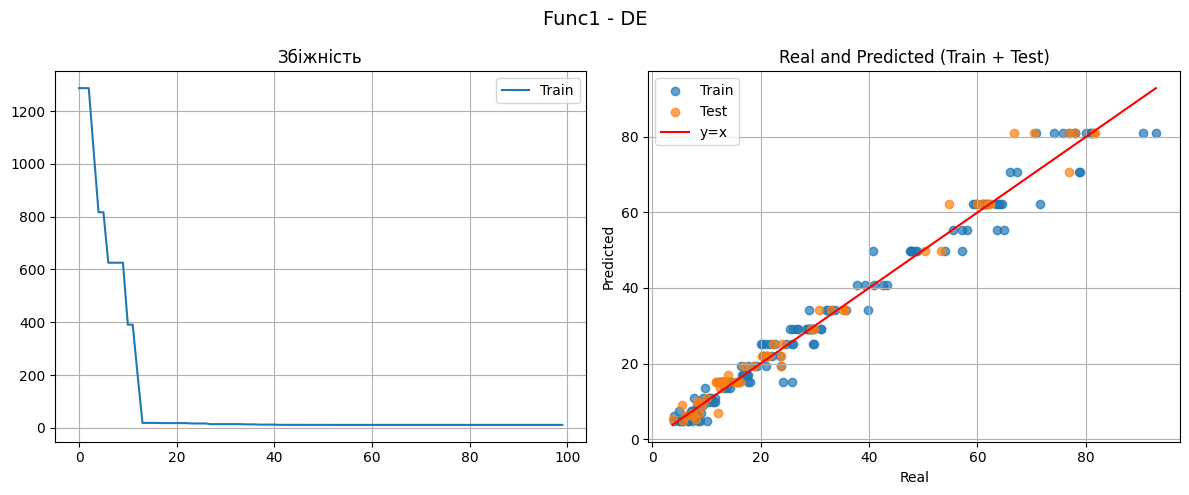

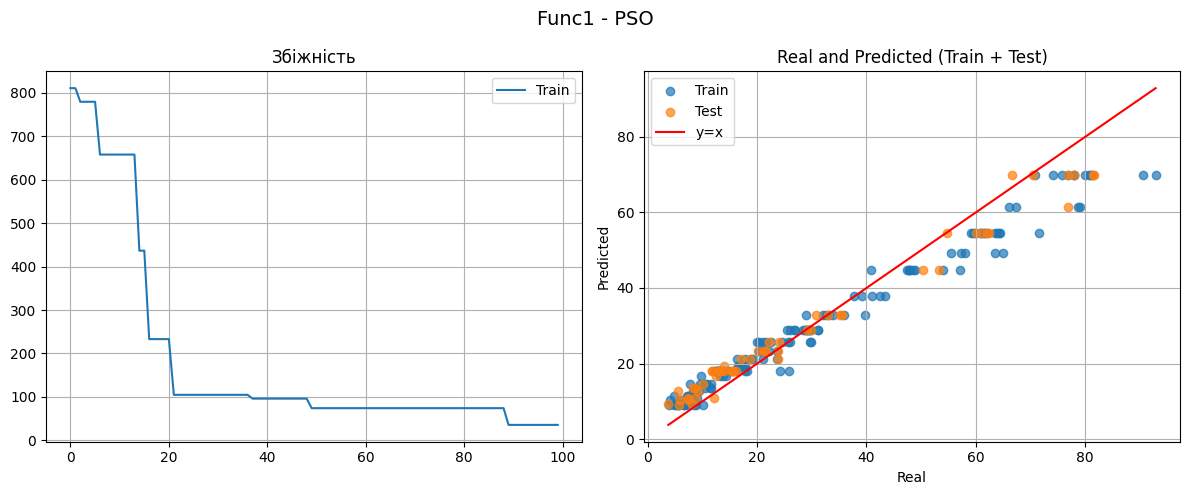


----------- Func2 ----------


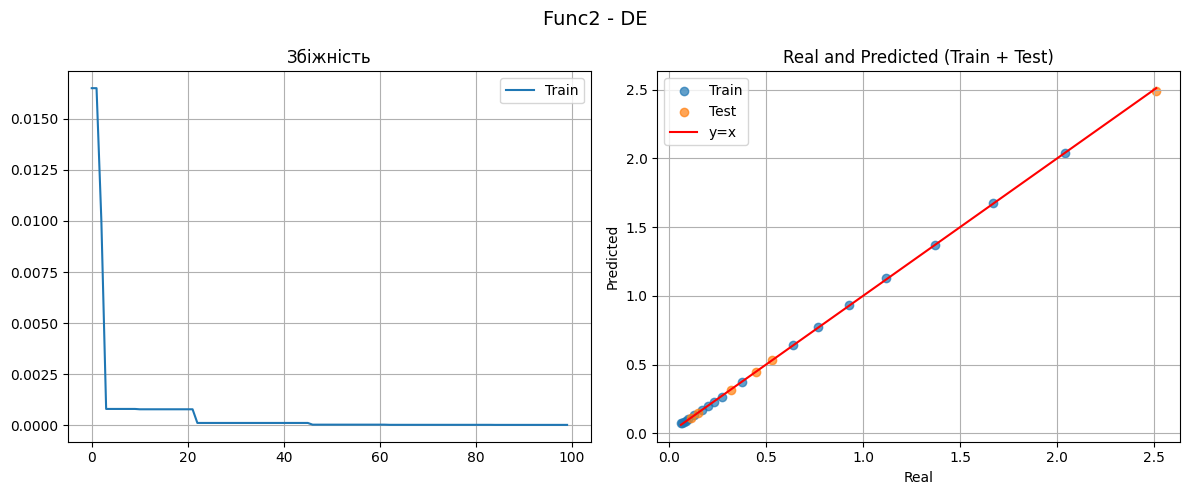

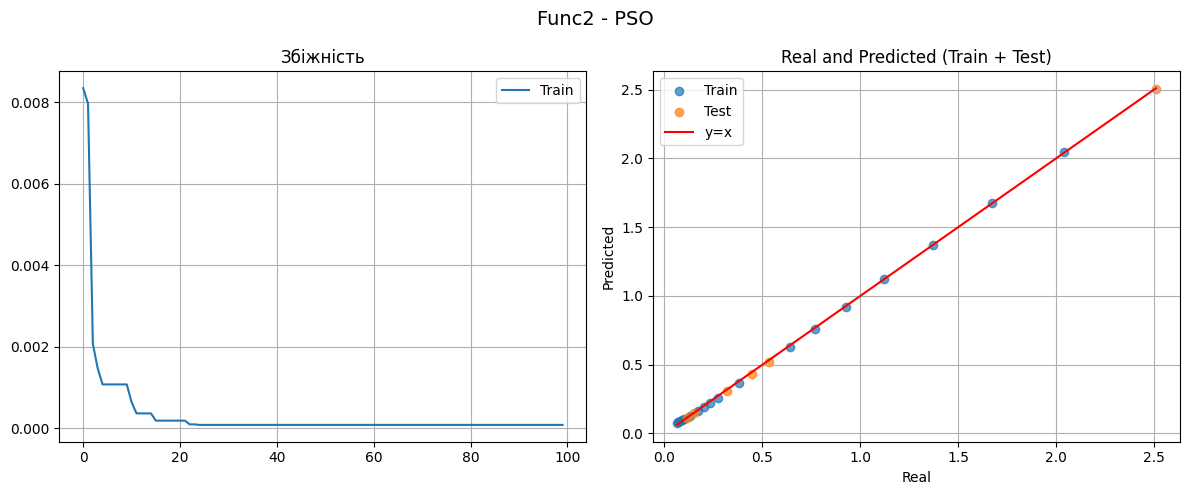


----------- Func3 ----------


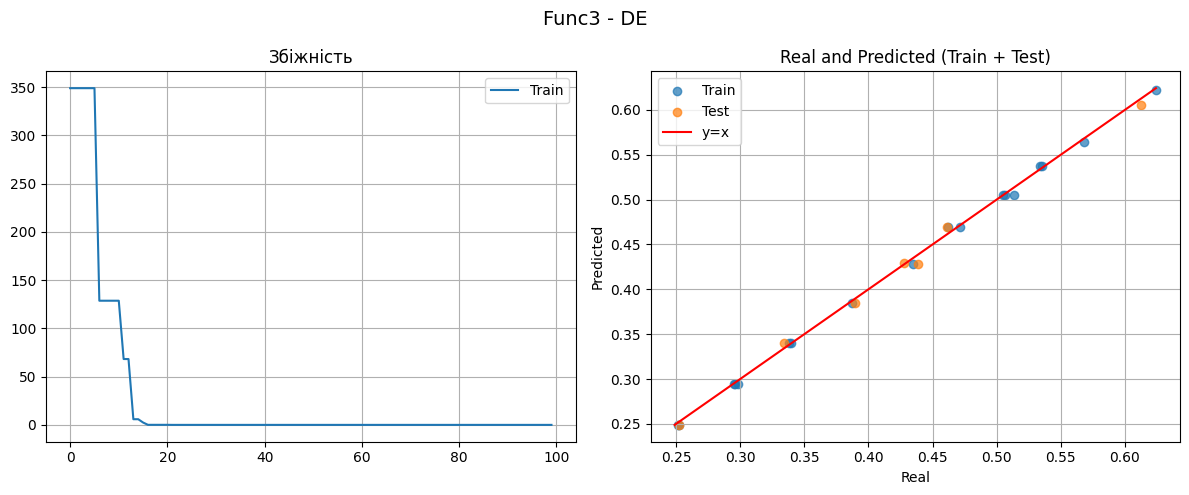

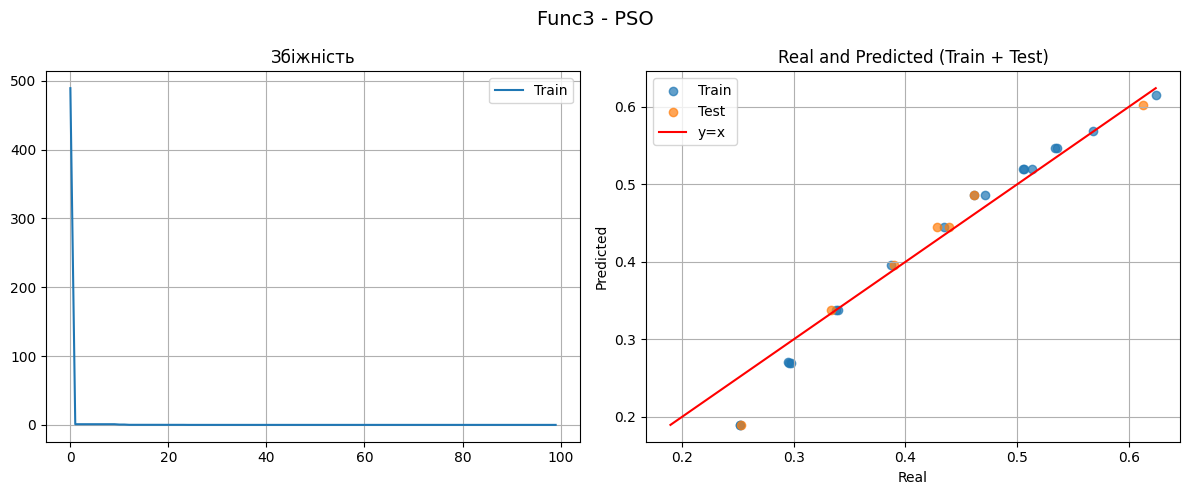

In [35]:
results = []

for name, f_info in functions.items():
    
    print(f"\n----------- {name} ----------")

    func = f_info["function"]
    data_path = f_info["data"]
    bounds_dict = f_info["bounds"]

    bounds = list(bounds_dict.values())

    X, y = load_data(data_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, shuffle=True, random_state=42
    )

    def loss_func(params, func=func):
        y_pred = func(X_train, *params)
        return np.mean((y_train - y_pred) ** 2)


    def train_metrics(params):
        y_pred = func(X_train, *params)
        return (
            np.mean((y_train - y_pred) ** 2), 
            mae(y_train, y_pred),
            r2(y_train, y_pred)
        )

    def test_metrics(params):
        y_pred = func(X_test, *params)
        return (
            np.mean((y_test - y_pred) ** 2),  
            mae(y_test, y_pred),
            r2(y_test, y_pred)
        )

    best_params_de, best_error_de, history_de = differential_evolution(loss_func, bounds)

    de_train_mse, de_train_mae, de_train_r2 = train_metrics(best_params_de)
    de_test_mse, de_test_mae, de_test_r2 = test_metrics(best_params_de)

    plot(history_de, func, best_params_de,
         X_train, y_train, X_test, y_test,
         title=f"{name} - DE")


    best_params_pso, best_error_pso, history_pso = pso(loss_func, bounds)

    pso_train_mse, pso_train_mae, pso_train_r2 = train_metrics(best_params_pso)
    pso_test_mse, pso_test_mae, pso_test_r2 = test_metrics(best_params_pso)

    plot(history_pso, func, best_params_pso,
         X_train, y_train, X_test, y_test,
         title=f"{name} - PSO")

    results.append({
        "Model": name,
        "Method": "DE",
        "Train MSE": de_train_mse,
        "Test MSE": de_test_mse,
        "Train MAE": de_train_mae,
        "Test MAE": de_test_mae,
        "Train R2": de_train_r2,
        "Test R2": de_test_r2,
        "Params": np.round(best_params_de, 4)
    })

    results.append({
        "Model": name,
        "Method": "PSO",
        "Train MSE": pso_train_mse,
        "Test MSE": pso_test_mse,
        "Train MAE": pso_train_mae,
        "Test MAE": pso_test_mae,
        "Train R2": pso_train_r2,
        "Test R2": pso_test_r2,
        "Params": np.round(best_params_pso, 4)
    })

In [36]:
df_results = pd.DataFrame(results)

print("\n-------- Метрики --------")
print(df_results[[
    "Model", "Method",
    "Train MSE", "Test MSE",
    "Train MAE", "Test MAE",
    "Train R2", "Test R2"
]])

print("\n-------- Параметри --------")
print(df_results[["Model", "Method", "Params"]])


-------- Метрики --------
   Model Method  Train MSE   Test MSE  Train MAE  Test MAE  Train R2   Test R2
0  Func1     DE  11.201792  11.680578   2.281723  2.235779  0.979728  0.979619
1  Func1    PSO  35.648926  27.203688   4.530975  4.241843  0.935487  0.952533
2  Func2     DE   0.000030   0.000088   0.004620  0.005812  0.999917  0.999873
3  Func2    PSO   0.000076   0.000088   0.007574  0.007914  0.999785  0.999873
4  Func3     DE   0.000014   0.000044   0.003025  0.005907  0.998889  0.995967
5  Func3    PSO   0.000648   0.000729   0.018486  0.019050  0.950212  0.932611

-------- Параметри --------
   Model Method                                            Params
0  Func1     DE                          [0.1748, 0.0057, 0.0112]
1  Func1    PSO                          [0.0191, 0.0065, 0.0154]
2  Func2     DE     [0.0821, 0.4017, 0.0, 8.1004, 2.4059, 4.1238]
3  Func2    PSO  [0.0623, 0.0707, 0.8882, 4.0048, 1.5557, 4.2689]
4  Func3     DE                [0.2018, -0.0, 1229.72, -163.7